In [1]:
!gdown --fuzzy 'https://drive.google.com/file/d/1c4k3ZZRblNZCByLEb2OCcfDVEpQKYODK/view?usp=sharing'

Downloading...
From (original): https://drive.google.com/uc?id=1c4k3ZZRblNZCByLEb2OCcfDVEpQKYODK
From (redirected): https://drive.google.com/uc?id=1c4k3ZZRblNZCByLEb2OCcfDVEpQKYODK&confirm=t&uuid=6fc8c5d9-9c1a-4062-a557-54a72153c8c0
To: /content/X_norm.zip
100% 2.29G/2.29G [00:28<00:00, 81.1MB/s]


In [2]:
!unzip /content/X_norm.zip -d /content/dataset/

Archive:  /content/X_norm.zip
  inflating: /content/dataset/X_norm.npy  
  inflating: /content/dataset/y.npy  


In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from sklearn.model_selection import train_test_split

In [3]:
X = np.load("/content/dataset/X_norm.npy")
y = np.load("/content/dataset/y.npy")

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [5]:
#For classification it's X_train, and y_cls(0/1)
y_train_cls = np.array([1 if np.any(mask == 1) else 0 for mask in y_train])
#For segment detection it's X_forged(containing forged images only) and y_forged(containing forged image's masks only)
forged_idx = np.where(np.any(y_train == 1, axis=(1,2,3)))[0]
X_train_forged = X_train[forged_idx]
y_train_forged = y_train[forged_idx]
#Same for tes
y_test_cls = np.array([1 if np.any(mask == 1) else 0 for mask in y_test])

forged_idx_test = np.where(np.any(y_test == 1, axis=(1,2,3)))[0]
X_test_forged = X_test[forged_idx_test]
y_test_forged = y_test[forged_idx_test]

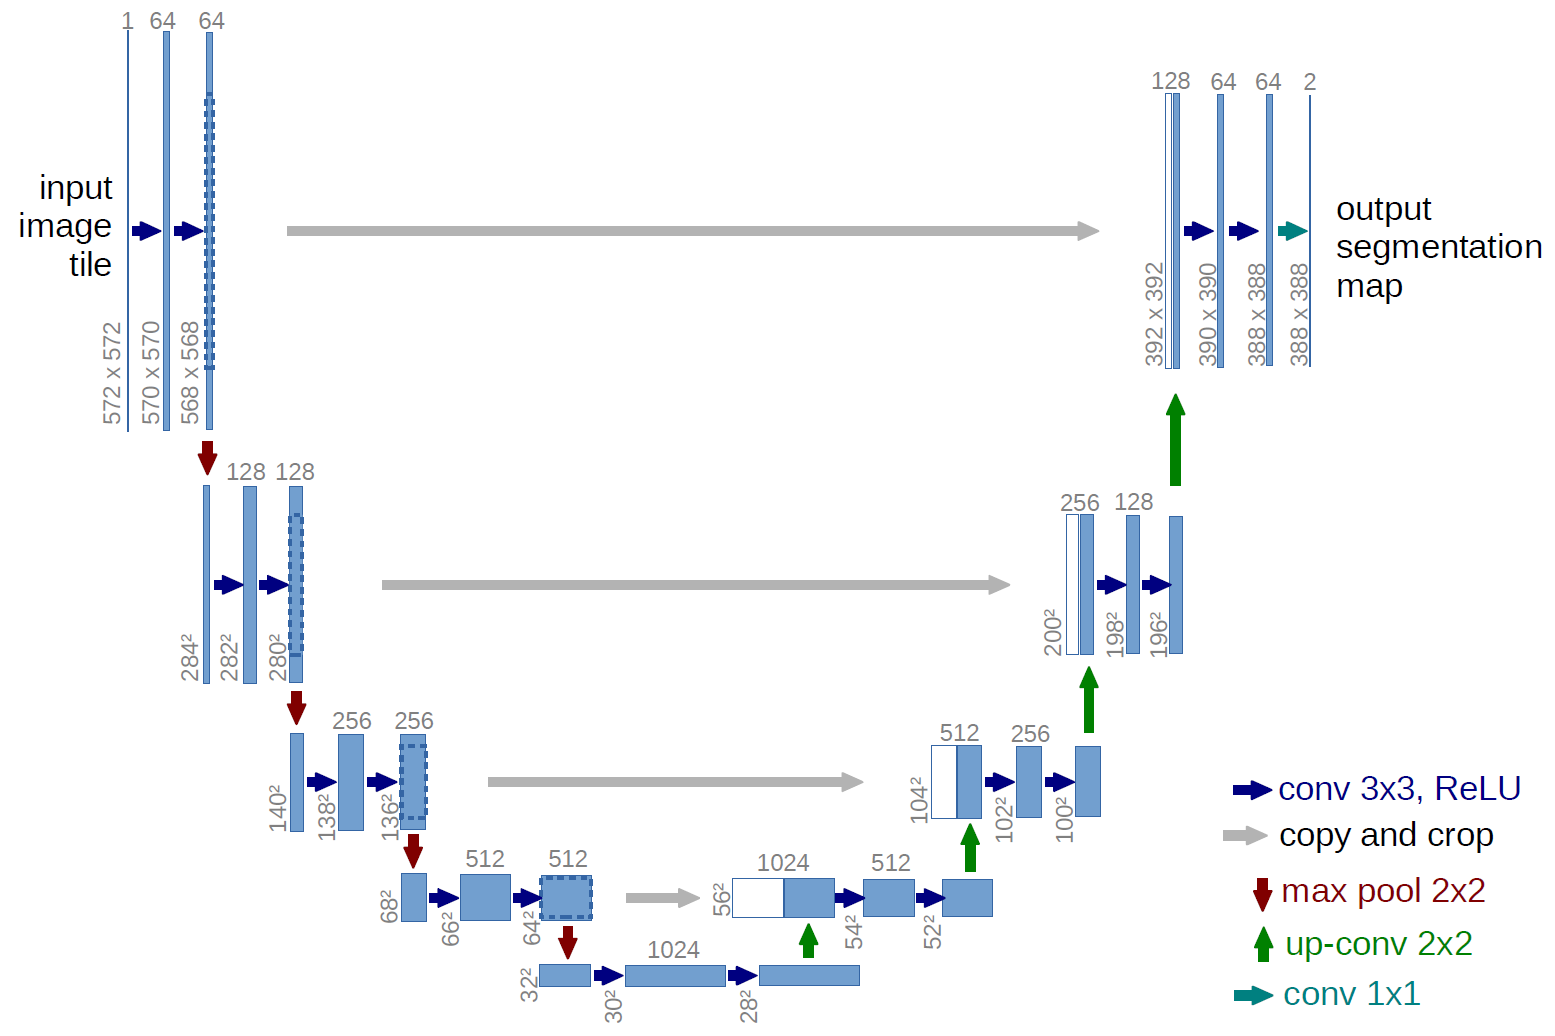

In [6]:
IMG_W = 512
IMG_H = 512
IMG_CHANNEL = 3


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomFlip("vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

def build_classifier():
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_H, IMG_W, IMG_CHANNEL)
    )
    base_model.trainable = True

    inputs = tf.keras.layers.Input((IMG_H, IMG_W, IMG_CHANNEL))
    x = data_augmentation(inputs)
    x = tf.keras.layers.Lambda(lambda x: tf.cast(x, tf.float32))(x)
    x = base_model(x, training=True)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    output = tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32')(x)
    return tf.keras.Model(inputs=[inputs], outputs=[output])

def build_UNet():
  inputs = tf.keras.layers.Input((IMG_W, IMG_H, IMG_CHANNEL))
  #Encoder
  c1 = tf.keras.layers.Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(inputs)
  c1 = tf.keras.layers.Dropout(0.1)(c1)
  c1 = tf.keras.layers.Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(c1)
  p1 = tf.keras.layers.MaxPooling2D((2,2))(c1)

  c2 = tf.keras.layers.Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(p1)
  c2 = tf.keras.layers.Dropout(0.1)(c2)
  c2 = tf.keras.layers.Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(c2)
  p2 = tf.keras.layers.MaxPooling2D((2,2))(c2)

  c3 = tf.keras.layers.Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(p2)
  c3 = tf.keras.layers.Dropout(0.1)(c3)
  c3 = tf.keras.layers.Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(c3)
  p3 = tf.keras.layers.MaxPooling2D((2,2))(c3)

  c4 = tf.keras.layers.Conv2D(256, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(p3)
  c4 = tf.keras.layers.Dropout(0.1)(c4)
  c4 = tf.keras.layers.Conv2D(256, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(c4)
  p4 = tf.keras.layers.MaxPooling2D((2,2))(c4)

  #BottleNeck
  c5 = tf.keras.layers.Conv2D(512, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(p4)
  c5 = tf.keras.layers.Dropout(0.1)(c5)
  c5 = tf.keras.layers.Conv2D(512, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(c5)

  #Decoder
  u6 = tf.keras.layers.Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(c5)
  u6 = tf.keras.layers.concatenate([u6,c4])
  c6 = tf.keras.layers.Conv2D(256, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(u6)
  c6 = tf.keras.layers.Dropout(0.1)(c6)
  c6 = tf.keras.layers.Conv2D(256, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(c6)

  u7 = tf.keras.layers.Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(c6)
  u7 = tf.keras.layers.concatenate([u7,c3])
  c7 = tf.keras.layers.Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(u7)
  c7 = tf.keras.layers.Dropout(0.1)(c7)
  c7 = tf.keras.layers.Conv2D(128, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(c7)

  u8 = tf.keras.layers.Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c7)
  u8 = tf.keras.layers.concatenate([u8,c2])
  c8 = tf.keras.layers.Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(u8)
  c8 = tf.keras.layers.Dropout(0.1)(c8)
  c8 = tf.keras.layers.Conv2D(64, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(c8)

  u9 = tf.keras.layers.Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(c8)
  u9 = tf.keras.layers.concatenate([u9,c1])
  c9 = tf.keras.layers.Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(u9)
  c9 = tf.keras.layers.Dropout(0.1)(c9)
  c9 = tf.keras.layers.Conv2D(32, (3,3), activation='relu', kernel_initializer='he_normal', padding = 'same')(c9)

  outputs = tf.keras.layers.Conv2D(1, (1,1), activation='sigmoid', dtype='float32')(c9)
  return tf.keras.Model(inputs=[inputs], outputs=[outputs])

model_class = build_classifier()
model_forged = build_UNet()

def focal_dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)  # prevent log(0)

    # Focal loss
    alpha, gamma = 0.85, 2.0
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    p_t = tf.exp(-bce)
    focal = alpha * tf.pow(1 - p_t, gamma) * bce

    # Dice loss
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = 1 - (2. * intersection + 1) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1)

    return focal + dice


model_class.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5, clipnorm=1.0),  # halved
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)
model_forged.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=focal_dice_loss,  # the combined loss from earlier
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

In [7]:
model_class.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 512, 512, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 512, 512, 3)       0         
                                                                 
 lambda (Lambda)             (None, 512, 512, 3)       0         
                                                                 
 efficientnetb0 (Functional  (None, 16, 16, 1280)      4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               327936

In [8]:
model_forged.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 512, 512, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 512, 512, 32)         896       ['input_3[0][0]']             
                                                                                                  
 dropout_1 (Dropout)         (None, 512, 512, 32)         0         ['conv2d[0][0]']              
                                                                                                  
 conv2d_1 (Conv2D)           (None, 512, 512, 32)         9248      ['dropout_1[0][0]']           
                                                                                            

In [9]:
pos_pixels = np.sum(y_train_forged == 1)
neg_pixels = np.sum(y_train_forged == 0)
pos_weight = neg_pixels / pos_pixels
print(f"Forged images: {len(X_train_forged)}")
print(f"Pos weight: {pos_weight:.2f}")

Forged images: 2206
Pos weight: 17.27


In [12]:
callbacks_class = [
    tf.keras.callbacks.ModelCheckpoint('model_class.keras', verbose=1, save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=5, monitor='val_loss'),
]

results_class = model_class.fit(X_train, y_train_cls,
                validation_split=0.1,
                batch_size=8,
                epochs=25,
                callbacks=callbacks_class)

Epoch 1/25
462/462 [==============================] - ETA: 0s - loss: 0.7031 - accuracy: 0.5056 - precision: 0.5298 - recall: 0.6575 - auc: 0.4950
Epoch 1: val_loss improved from inf to 0.69166, saving model to model_class.keras
462/462 [==============================] - 109s 120ms/step - loss: 0.7031 - accuracy: 0.5056 - precision: 0.5298 - recall: 0.6575 - auc: 0.4950 - val_loss: 0.6917 - val_accuracy: 0.5158 - val_precision: 0.5533 - val_recall: 0.7957 - val_auc: 0.5048
Epoch 2/25
462/462 [==============================] - ETA: 0s - loss: 0.6958 - accuracy: 0.5383 - precision: 0.5543 - recall: 0.6915 - auc: 0.5300
Epoch 2: val_loss improved from 0.69166 to 0.68341, saving model to model_class.keras
462/462 [==============================] - 52s 112ms/step - loss: 0.6958 - accuracy: 0.5383 - precision: 0.5543 - recall: 0.6915 - auc: 0.5300 - val_loss: 0.6834 - val_accuracy: 0.5547 - val_precision: 0.5802 - val_recall: 0.8000 - val_auc: 0.5359
Epoch 3/25
462/462 [=====================

In [10]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('model_forge.keras', verbose=1, save_best_only = True),
    tf.keras.callbacks.EarlyStopping(patience=5, monitor='val_loss'),
    tf.keras.callbacks.TensorBoard(log_dir='logs')]

results_unet = model_forged.fit(X_train_forged, y_train_forged,
                    validation_split=0.1,
                    batch_size=8,
                    epochs=25,
                    callbacks=callbacks,
                    class_weight={0: 1.0, 1: pos_weight})

Epoch 1/25
249/249 [==============================] - ETA: 0s - loss: 1.9366 - accuracy: 0.5874 - precision: 0.0846 - recall: 0.6638
Epoch 1: val_loss improved from inf to 0.99460, saving model to model_forge.keras
249/249 [==============================] - 67s 150ms/step - loss: 1.9366 - accuracy: 0.5874 - precision: 0.0846 - recall: 0.6638 - val_loss: 0.9946 - val_accuracy: 0.8074 - val_precision: 0.1259 - val_recall: 0.4401
Epoch 2/25
248/249 [============================>.] - ETA: 0s - loss: 1.8452 - accuracy: 0.7440 - precision: 0.1382 - recall: 0.6999
Epoch 2: val_loss improved from 0.99460 to 0.94047, saving model to model_forge.keras
249/249 [==============================] - 32s 127ms/step - loss: 1.8455 - accuracy: 0.7440 - precision: 0.1382 - recall: 0.6994 - val_loss: 0.9405 - val_accuracy: 0.8768 - val_precision: 0.2040 - val_recall: 0.4525
Epoch 3/25
248/249 [============================>.] - ETA: 0s - loss: 1.8142 - accuracy: 0.7835 - precision: 0.1627 - recall: 0.7092
E

In [11]:
model_class = tf.keras.models.load_model('model_class.keras', safe_mode=False)

In [12]:
model_forged = tf.keras.models.load_model('model_forge.keras',
                                    custom_objects={'focal_dice_loss': focal_dice_loss})


In [13]:
print("Classifier Results")
model_class.evaluate(X_test, y_test_cls)

# Evaluate segmentation
print("\n Segmentation Results")
model_forged.evaluate(X_test_forged, y_test_forged)


Classifier Results
33/33 [==============================] - 7s 102ms/step - loss: 0.6501 - accuracy: 0.5400 - precision: 0.5698 - recall: 0.5468 - auc: 0.5998

 Segmentation Results
18/18 [==============================] - 7s 107ms/step - loss: 0.8155 - accuracy: 0.9045 - precision: 0.3171 - recall: 0.5818


[0.8154770135879517,
 0.9045253992080688,
 0.3170616030693054,
 0.5818372964859009]

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_prob = model_class.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test_cls, y_pred)
print(cm)

33/33 [==============================] - 5s 98ms/step
[[257 224]
 [236 309]]


In [15]:
y_pred_prob = model_class.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

X_test_forged_pred = X_test[y_pred == 1]
y_test_forged_pred = y_test[y_pred == 1]

print(f"Classifier flagged {len(X_test_forged_pred)} images as forged out of {len(X_test)}")
print(f"Of those, actually forged: {np.sum(np.any(y_test_forged_pred == 1, axis=(1,2,3)))}")

model_forged.evaluate(X_test_forged_pred, y_test_forged_pred)

33/33 [==============================] - 3s 98ms/step
Classifier flagged 534 images as forged out of 1026
Of those, actually forged: 311
17/17 [==============================] - 5s 296ms/step - loss: 0.8595 - accuracy: 0.9211 - precision: 0.2400 - recall: 0.6760


[0.8594954013824463,
 0.9210662245750427,
 0.24003635346889496,
 0.6759684085845947]

Total test images:        1026      
Flagged as forged:         570  (55.5%)    
Actually forged of those:  344  (60.4% precision of classifier)    
Missed forged images:      206  (forged but classified as authentic)

1/1 [==============================] - 0s 244ms/step


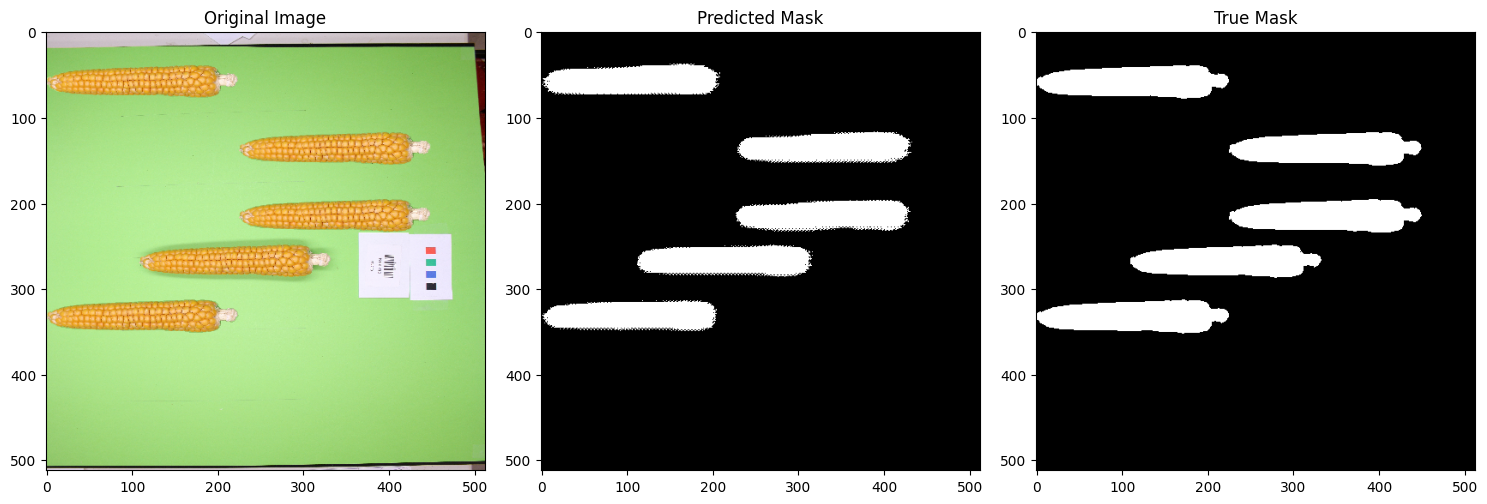

In [16]:
img = X_test_forged[2]
true_mask = y_test_forged[2]

# Predict mask
pred_mask = model_forged.predict(img[np.newaxis,...])[0]
pred_binary = (pred_mask > 0.5).astype(np.uint8)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[1].imshow(pred_binary[:,:,0], cmap='gray')
axes[1].set_title('Predicted Mask')
axes[2].imshow(true_mask[:,:,0], cmap='gray')
axes[2].set_title('True Mask')
plt.tight_layout()
plt.show()

In [23]:
from google.colab import runtime
runtime.unassign()